In [1]:
#!uv pip install -r requirements.txt --prerelease=allow

# 1. Loading & preprocessing data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import requests

def gbp_to_eur_live(gbp_amount):
    """
    Convierte GBP a EUR usando una API de tipos de cambio en tiempo real.
    """
    url = "https://api.exchangerate-api.com/v4/latest/GBP"
    try:
        response = requests.get(url)
        data = response.json()
        eur_rate = data["rates"]["EUR"]
        return gbp_amount * eur_rate
    except Exception as e:
        print("Error al obtener el tipo de cambio:", e)
        return None

In [3]:
autumn_horses_df = pd.read_csv('data/Autumn Horses In Training Sale 2009-2024.csv')
autumn_horses_df.info()
autumn_horses_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 26076 entries, 0 to 26075
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Day             26076 non-null  int64  
 1   Lot             26076 non-null  str    
 2   Name            26076 non-null  str    
 3   Sex             26054 non-null  str    
 4   Colour          26053 non-null  str    
 5   Sire            26049 non-null  str    
 6   Dam             26049 non-null  str    
 7   Year Foaled     26054 non-null  float64
 8   Date Foaled     26054 non-null  str    
 9   Grandsire       26024 non-null  str    
 10  Damsire         26024 non-null  str    
 11  Covered by      6 non-null      str    
 12  Consignor       26049 non-null  str    
 13  Purchaser       26076 non-null  str    
 14  Price (gns)     18695 non-null  str    
 15  Stabling        454 non-null    str    
 16  Año Subasta     26076 non-null  int64  
 17  Nombre Subasta  26076 non-null  str    
 1

,Day,Lot,Name,Sex,Colour,Sire,Dam,Year Foaled,Date Foaled,Grandsire,...,Price (gns),Stabling,Año Subasta,Nombre Subasta,Price (€),ORIG,SIRE_N,DAM_N,SIREDAM_N,BREEDER_N
0,3,1067,Qirat (GB),G,Ch,Showcasing (GB),Emulous (GB),2021.0,22/2/2021,Oasis Dream (GB),...,NaN,NaN,2024,Autumn Horses In Training Sale 2024,-,2021SHOWCASINGEMULOUS,SHOWCASING,EMULOUS,DANSILI,JUDDMONTE
1,2,639,Gifted Master (IRE),G,B,Kodiac (GB),Shobobb (GB),2013.0,3/4/2013,Danehill (USA),...,NaN,NaN,2019,Autumn Horses in Training Sale 2019,-,2013KODIACSHOBOBB,KODIAC,SHOBOBB,SHAMARDAL,THE CASTLEBRIDGE CONSIGNMENT
2,2,568,Commanche Falls (GB),G,Br,Lethal Force (IRE),Joyeaux (GB),2017.0,28/4/2017,Dark Angel (IRE),...,NaN,NaN,2020,Autumn Horses In Training Sale 2020,-,2017LETHAL FORCEJOYEAUX,LETHAL FORCE,JOYEAUX,MARK OF ESTEEM,DENTON HALL STABLES
3,2,764,Summerghand (IRE),G,B,Lope de Vega (IRE),Kate The Great (GB),2014.0,6/3/2014,Shamardal (USA),...,90.000,NaN,2020,Autumn Horses In Training Sale 2020,108.675,2014LOPE DE VEGAKATE THE GREAT,LOPE DE VEGA,KATE THE GREAT,XAAR,DAVID O'MEARA RACING LTD.
4,2,691,Regal Reality (GB),G,B,Intello (GER),Regal Realm (GB),2015.0,20/2/2015,Galileo (IRE),...,NaN,NaN,2020,Autumn Horses In Training Sale 2020,-,2015INTELLOREGAL REALM,INTELLO,REGAL REALM,MEDICEAN,FREEMASON LODGE STABLES


In [4]:
# Normalise column names
print("Before normalising names:",autumn_horses_df.columns)
col_names_to_normalise = [col for col in autumn_horses_df.columns if col.strip() != col]
for col_name in col_names_to_normalise:
    autumn_horses_df[col_name.strip()] = autumn_horses_df[col_name]
    autumn_horses_df.drop(columns=[col_name],inplace=True)
print("After normalising names:",autumn_horses_df.columns)

Before normalising names: Index(['Day', 'Lot', 'Name', 'Sex', 'Colour', 'Sire', 'Dam', 'Year Foaled',
       'Date Foaled', 'Grandsire', 'Damsire', 'Covered by', 'Consignor',
       'Purchaser', 'Price (gns)', 'Stabling', 'Año Subasta', 'Nombre Subasta',
       ' Price (€)', ' ORIG', ' SIRE_N', ' DAM_N', ' SIREDAM_N', ' BREEDER_N'],
      dtype='str')
After normalising names: Index(['Day', 'Lot', 'Name', 'Sex', 'Colour', 'Sire', 'Dam', 'Year Foaled',
       'Date Foaled', 'Grandsire', 'Damsire', 'Covered by', 'Consignor',
       'Purchaser', 'Price (gns)', 'Stabling', 'Año Subasta', 'Nombre Subasta',
       'Price (€)', 'ORIG', 'SIRE_N', 'DAM_N', 'SIREDAM_N', 'BREEDER_N'],
      dtype='str')


In [5]:
autumn_horses_df[autumn_horses_df['Covered by'].notnull()][['Name','Sex','Covered by']]

,Name,Sex,Covered by
558,Our Little Pony (GB),M,El Kabeir (USA)
1062,Made of Honour (IRE),M,Havana Grey (GB)
7509,Casima (GB),M,Washington DC (IRE)
9611,Carraigin Aonair (IRE),M,Footstepsinthesand (GB)
12997,Exoplanet Blue (GB),M,Bated Breath (GB)
24138,Stan's Cool Cat (IRE),M,Teofilo (IRE)


In [6]:
autumn_horses_df[autumn_horses_df['Stabling'].notnull()].shape

(454, 24)

Data dictionary:
* `Day`: Day of the sale (1-5) -> 1-3 (premium) vs 4-5 (secondary market). 1: Monday, 2: Tuesday, 3: Wednesday, 4: Thursday, 5: Friday
* `Año Subasta`: Year of the sale (2009-2025)
* `Name`: Name of the horse
* `Sex`: Sex of the horse
* `Sire`: Sire of the horse
* `Dam`: Dam of the horse
* `ORIG`: Origin of the horse
* `Year Foaled`: Year of foaling of the horse
* `Purchaser`: Purchaser of the horse
* `Price (gns)`: Price of the horse in guineas
* `Price (€)`: Price of the horse in euros
* `sold`: Whether the horse was sold or not
* `Grandsire`: Grandsire of the horse
* `Damsire`: Damsire of the horse
* `Covered by`: Stallion that covered the horse
* `Stabling`: Whether the horse was stabled
* `ORIG`: Origin of the horse
* `Year Foaled`: Year of foaling of the horse
* `Purchaser`: Purchaser of the horse
* `Price (gns)`: Price of the horse in guineas
* `Price (€)`: Price of the horse in euros
* `SIRE_N`: Normalised sire of the horse
* `DAM_N`: Normalised dam of the horse
* `SIREDAM_N`: Normalised damsire of the horse
* `BREEDER_N`: Normalised consignor of the horse
* `Nombre Subasta`: Name of the sale

In [7]:
autumn_horses_df['price_gns'] = autumn_horses_df['Price (gns)'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype('double')
autumn_horses_df['price_euros'] = gbp_to_eur_live(autumn_horses_df['price_gns']*1.05)
autumn_horses_df.drop(columns=['Price (gns)','Price (€)'],inplace=True)

In [8]:
# Celda nueva — entender ORIG
display(autumn_horses_df['ORIG'].value_counts().head(10))
display(autumn_horses_df[['ORIG','Year Foaled', 'Sire','Dam']].head(10))

ORIG
                                  22
2008HAAFHDATNAB                    5
2010EXCELLENT ARTIVY QUEEN         4
2011ART CONNOISSEURSUZI SPENDS     4
2012LOPE DE VEGAGORBAND            4
2010ELNADIMELUTRAH                 4
2009MOTIVATORELA ATHENA            4
2007CAMACHOMISS INDIGO             4
2009TEOFILOFIELD OF HOPE           4
2009MONTJEUTIME OVER               4
Name: count, dtype: int64

,ORIG,Year Foaled,Sire,Dam
0,2021SHOWCASINGEMULOUS,2021.0,Showcasing (GB),Emulous (GB)
1,2013KODIACSHOBOBB,2013.0,Kodiac (GB),Shobobb (GB)
2,2017LETHAL FORCEJOYEAUX,2017.0,Lethal Force (IRE),Joyeaux (GB)
3,2014LOPE DE VEGAKATE THE GREAT,2014.0,Lope de Vega (IRE),Kate The Great (GB)
4,2015INTELLOREGAL REALM,2015.0,Intello (GER),Regal Realm (GB)
5,2014FAMOUS NAMESAYING GRACE,2014.0,Famous Name (GB),Saying Grace (IRE)
6,2016SHAMARDALSPIRIT OF DUBAI,2016.0,Shamardal (USA),Spirit of Dubai (IRE)
7,2019MUHAARARSHIMAH,2019.0,Muhaarar (GB),Shimah (USA)
8,2015EXCELEBRATIONMAGLIETTA FINA,2015.0,Excelebration (IRE),Maglietta Fina (IRE)
9,2017HEERAATNIGELLA,2017.0,Heeraat (IRE),Nigella (GB)


In [9]:
# Comprueba que _N realmente normaliza bien
autumn_horses_df[['Sire', 'SIRE_N', 'Consignor', 'BREEDER_N']].head(20)

,Sire,SIRE_N,Consignor,BREEDER_N
0,Showcasing (GB),SHOWCASING,Juddmonte,JUDDMONTE
1,Kodiac (GB),KODIAC,The Castlebridge Consignment,THE CASTLEBRIDGE CONSIGNMENT
2,Lethal Force (IRE),LETHAL FORCE,Denton Hall Stables (M. Dods),DENTON HALL STABLES
3,Lope de Vega (IRE),LOPE DE VEGA,David O'Meara Racing Ltd.,DAVID O'MEARA RACING LTD.
4,Intello (GER),INTELLO,Freemason Lodge Stables (Sir M. Stoute),FREEMASON LODGE STABLES
5,Famous Name (GB),FAMOUS NAME,The Castlebridge Consignment,THE CASTLEBRIDGE CONSIGNMENT
6,Shamardal (USA),SHAMARDAL,Hambleton Lodge Stables (K. Ryan),HAMBLETON LODGE STABLES
7,Muhaarar (GB),MUHAARAR,Shadwell Estate Company Ltd.,SHADWELL ESTATE COMPANY LTD.
8,Excelebration (IRE),EXCELEBRATION,The Castlebridge Consignment,THE CASTLEBRIDGE CONSIGNMENT
9,Heeraat (IRE),HEERAAT,Belstane Racing Stables (K. Dalgleish),BELSTANE RACING STABLES


In [10]:
autumn_horses_df[['Grandsire', 'Damsire','SIREDAM_N']].head(20)

,Grandsire,Damsire,SIREDAM_N
0,Oasis Dream (GB),Dansili (GB),DANSILI
1,Danehill (USA),Shamardal (USA),SHAMARDAL
2,Dark Angel (IRE),Mark of Esteem (IRE),MARK OF ESTEEM
3,Shamardal (USA),Xaar (GB),XAAR
4,Galileo (IRE),Medicean (GB),MEDICEAN
5,Dansili (GB),Brief Truce (USA),BRIEF TRUCE
6,Giant's Causeway (USA),Cape Cross (IRE),CAPE CROSS
7,Oasis Dream (GB),Storm Cat (USA),STORM CAT
8,Exceed And Excel (AUS),Verglas (IRE),VERGLAS
9,Dark Angel (IRE),Band On The Run,BAND ON THE RUN


In [11]:
# TODO feature engineering: crear sire_dam_combo
# autumn_horses_df['sire_dam_combo'] = autumn_horses_df['SIRE_N'] + '_x_' + autumn_horses_df['DAM_N']
# TODO feature engineering: revisar nombres de todas columnas, ver que eliminar

In [12]:
int(autumn_horses_df['price_gns'].isna().sum()),int(autumn_horses_df['price_gns'].notnull().sum())

(7381, 18695)

In [13]:
autumn_horses_df['year'] = autumn_horses_df['Year Foaled'].astype('Int64')

In [14]:
autumn_horses_df['Purchaser'].value_counts().head(5)

Purchaser
Lot Withdrawn                    7081
Vendor                           1383
Lot Not Sold                     1081
BBA Ireland                       201
Oliver St Lawrence Bloodstock     159
Name: count, dtype: int64

In [15]:
autumn_horses_df['sold'] = (~autumn_horses_df['Purchaser'].isin(['Lot Withdrawn', 'Lot Not Sold', 'Vendor'])) & autumn_horses_df['price_gns'].notna()

In [16]:
autumn_horses_df['sold'].value_counts()

sold
True     16531
False     9545
Name: count, dtype: int64

In [17]:
# Verificación
display(autumn_horses_df.groupby('sold')['price_gns'].apply(lambda x: x.notna().value_counts()))
print(f"\nVendor con precio: {autumn_horses_df[autumn_horses_df['Purchaser']=='Vendor']['price_gns'].notna().sum()}")
print(f"Not Sold con precio: {autumn_horses_df[autumn_horses_df['Purchaser']=='Lot Not Sold']['price_gns'].notna().sum()}")

sold        
False  False     7381
       True      2164
True   True     16531
Name: price_gns, dtype: int64


Vendor con precio: 1383
Not Sold con precio: 781


In [18]:
# 2. Distribución temporal
by_year = autumn_horses_df.groupby('Año Subasta').agg(
    total=('sold', 'count'),
    vendidos=('sold', 'sum')
)
by_year['pct_vendido'] = by_year['vendidos'] / by_year['total'] * 100
by_year['precio_mediano'] = autumn_horses_df[autumn_horses_df['sold']==1].groupby('Año Subasta')['price_gns'].apply(
        lambda x: pd.to_numeric(x.astype(str).str.replace(',',''), errors='coerce').median()
    )
by_year

,total,vendidos,pct_vendido,precio_mediano
Año Subasta,,,,
2009,1533,903,58.904110,9000.0
2010,1583,865,54.643083,9000.0
2011,1478,848,57.374831,9000.0
2012,1429,909,63.610917,11000.0
2013,1518,894,58.893281,10000.0
2014,1539,922,59.909032,13000.0
2015,1679,1038,61.822513,10000.0
2016,1516,949,62.598945,13500.0
2017,1650,1065,64.545455,11000.0


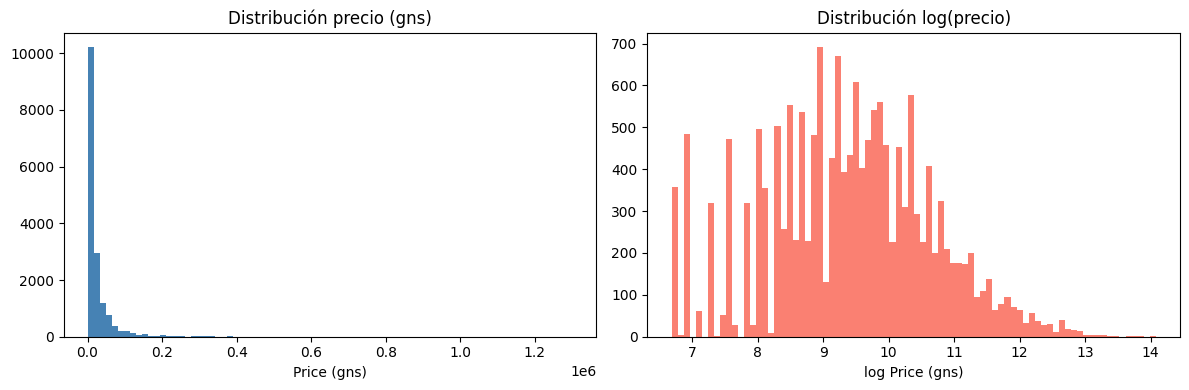

Skewness sin log: 6.98
Skewness con log: 0.03


In [19]:
df_sold = autumn_horses_df[autumn_horses_df['sold']==1].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sin transformar — verás la cola pesada
axes[0].hist(df_sold['price_gns'].dropna(), bins=80, color='steelblue')
axes[0].set_title('Distribución precio (gns)')
axes[0].set_xlabel('Price (gns)')

# Log-transformado — verás la normalidad aproximada
axes[1].hist(np.log(df_sold['price_gns'].dropna()), bins=80, color='salmon')
axes[1].set_title('Distribución log(precio)')
axes[1].set_xlabel('log Price (gns)')

plt.tight_layout()
plt.show()

print(f"Skewness sin log: {df_sold['price_gns'].skew():.2f}")
print(f"Skewness con log: {np.log(df_sold['price_gns']).skew():.2f}")

In [20]:
# 4. Top variables categóricas
print("=== TOP 15 SIRES (precio mediano, mín 15 ventas) ===")
sire_stats = df_sold.groupby('SIRE_N')['price_gns'].agg(['median','count'])\
    .query('count >= 15').sort_values('median', ascending=False).head(15)
display(sire_stats)

print("\n=== TOP 15 CONSIGNORS (precio mediano, mín 20 ventas) ===")
cons_stats = df_sold.groupby('BREEDER_N')['price_gns'].agg(['median','count'])\
    .query('count >= 20').sort_values('median', ascending=False).head(15)
display(cons_stats)

=== TOP 15 SIRES (precio mediano, mín 15 ventas) ===


,median,count
SIRE_N,,
POSTPONED,32000.0,16
FRANKEL,32000.0,109
MIZZEN MAST,30000.0,37
DUBAWI,30000.0,177
DYNAFORMER,30000.0,21
FIRST DEFENCE,30000.0,15
AZAMOUR,30000.0,38
SIOUX NATION,28500.0,32
KENDARGENT,28500.0,16



=== TOP 15 CONSIGNORS (precio mediano, mín 20 ventas) ===


,median,count
BREEDER_N,,
JUDDMONTE,60000.0,50
IMPERIUM SALES,50000.0,40
MOYGLARE STUD FARM LTD.,33500.0,26
COOLMORE,31000.0,115
"SOMERVILLE LODGE LTD., AGENT",30000.0,141
KINGSCLERE TRAINING STABLES,26500.0,60
"CURRABEG STABLES, IRELAND",25000.0,32
JUDDMONTE FARMS,22000.0,457
FREEMASON LODGE STABLES,22000.0,214


In [21]:
day_stats = df_sold.groupby('Day')['price_gns'].agg(['mean','median','count','std']).round(0)
rna_by_day = autumn_horses_df.groupby('Day').agg(
    total=('sold','count'), vendidos=('sold','sum'))
rna_by_day['pct_rna'] = (1 - rna_by_day['vendidos']/rna_by_day['total'])*100
display(day_stats)
display(rna_by_day.round(1))

,mean,median,count,std
Day,,,,
1,24932.0,12000.0,4135,39274.0
2,34719.0,17000.0,4180,60539.0
3,34438.0,17000.0,4574,56803.0
4,8239.0,5000.0,3261,11894.0
5,7140.0,4000.0,381,8533.0


,total,vendidos,pct_rna
Day,,,
1,6823,4135,39.4
2,6472,4180,35.4
3,6770,4574,32.4
4,5289,3261,38.3
5,722,381,47.2


In [22]:
print(df_sold.groupby('Sex')['price_gns'].agg(['median','count']))
# La tasa de venta la sacas por separado
print(autumn_horses_df.groupby('Sex')['sold'].agg(['sum','count']))

      median  count
Sex                
C    17000.0   4466
F     7000.0   4031
G    13000.0   7867
H    22000.0     88
M     5500.0     78
R    45000.0      1
      sum  count
Sex             
C    4466   7403
F    4031   6331
G    7867  12002
H      88    162
M      78    155
R       1      1


In [23]:
print(df_sold.groupby('Year Foaled')['price_gns'].agg(['median','count']))

              median  count
Year Foaled                
2002.0        3500.0      4
2003.0        4000.0     15
2004.0       14000.0     48
2005.0       13000.0    185
2006.0       10000.0    629
2007.0        8500.0    929
2008.0        8000.0    865
2009.0       11000.0    954
2010.0       11000.0    835
2011.0       11500.0    949
2012.0       12000.0   1046
2013.0       11000.0    996
2014.0       13000.0   1001
2015.0       12000.0   1037
2016.0       12000.0    984
2017.0       11000.0   1002
2018.0       13500.0    947
2019.0       16000.0   1020
2020.0       15000.0    971
2021.0       16000.0   1016
2022.0       15000.0    815
2023.0       15000.0    283


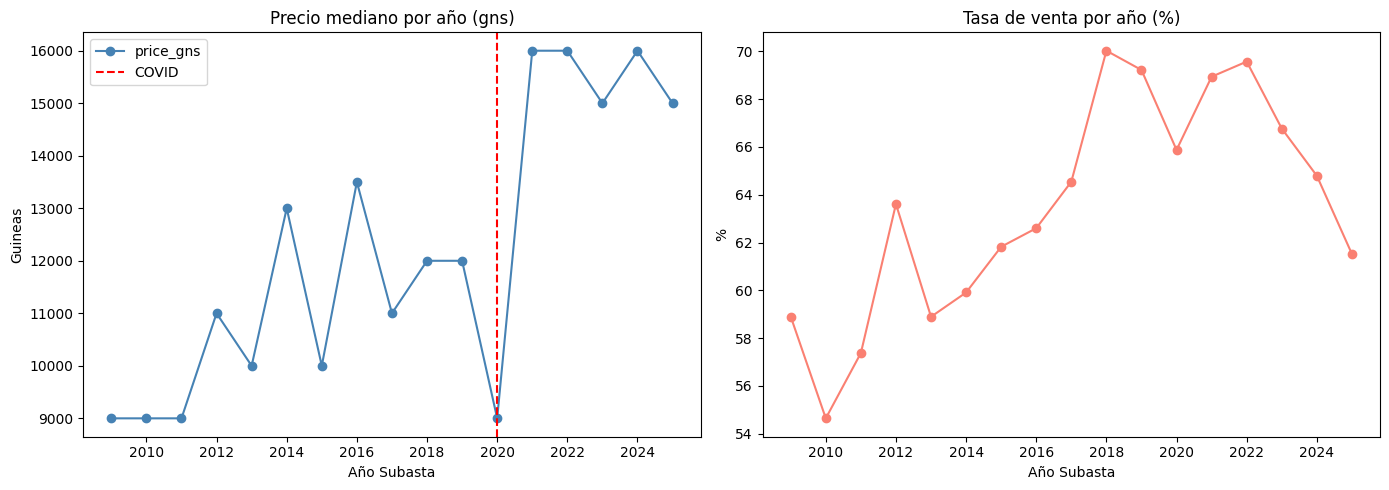

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_year_plot = autumn_horses_df[autumn_horses_df['sold']==1]\
    .groupby('Año Subasta')['price_gns'].median()
by_year_plot.plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Precio mediano por año (gns)')
axes[0].set_ylabel('Guineas')
axes[0].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[0].legend()

# Tasa de venta por año
pct_by_year = autumn_horses_df.groupby('Año Subasta')['sold'].mean() * 100
pct_by_year.plot(ax=axes[1], marker='o', color='salmon')
axes[1].set_title('Tasa de venta por año (%)')
axes[1].set_ylabel('%')
plt.tight_layout()
plt.show()

In [25]:
sex_rate = autumn_horses_df.groupby('Sex')['sold'].agg(['sum','count'])
sex_rate['pct_vendido'] = sex_rate['sum'] / sex_rate['count'] * 100
print(sex_rate.round(1))

      sum  count  pct_vendido
Sex                          
C    4466   7403         60.3
F    4031   6331         63.7
G    7867  12002         65.5
H      88    162         54.3
M      78    155         50.3
R       1      1        100.0


In [26]:
print("=== RESUMEN ===")
print(f"Total registros: {len(autumn_horses_df):,}")
print(f"Periodo: {autumn_horses_df['Año Subasta'].min()} - {autumn_horses_df['Año Subasta'].max()}")
print(f"Vendidos a terceros: {autumn_horses_df['sold'].sum():,} ({autumn_horses_df['sold'].mean()*100:.1f}%)")
print(f"RNA (Reserve Not Attained) total: {(~autumn_horses_df['sold']).sum():,} ({(1-autumn_horses_df['sold'].mean())*100:.1f}%)")
print(f"  - Lot Withdrawn: {(autumn_horses_df['Purchaser']=='Lot Withdrawn').sum():,}")
print(f"  - Lot Not Sold:  {(autumn_horses_df['Purchaser']=='Lot Not Sold').sum():,}")
print(f"  - Vendor buyback:{(autumn_horses_df['Purchaser']=='Vendor').sum():,}")
print(f"Precio mediano (vendidos): {autumn_horses_df[autumn_horses_df['sold']]['price_gns'].median():,.0f} gns ≈ {autumn_horses_df[autumn_horses_df['sold']]['price_euros'].median():,.0f} euros")
print(f"Precio máximo: {autumn_horses_df['price_gns'].max():,.0f} gns ≈ {autumn_horses_df['price_euros'].max():,.0f} euros")
print(f"Sires únicos: {autumn_horses_df['SIRE_N'].nunique()}")
print(f"Consignors únicos: {autumn_horses_df['BREEDER_N'].nunique()}")

=== RESUMEN ===
Total registros: 26,076
Periodo: 2009 - 2025
Vendidos a terceros: 16,531 (63.4%)
RNA (Reserve Not Attained) total: 9,545 (36.6%)
  - Lot Withdrawn: 7,081
  - Lot Not Sold:  1,081
  - Vendor buyback:1,383
Precio mediano (vendidos): 12,000 gns ≈ 14,616 euros
Precio máximo: 1,300,000 gns ≈ 1,583,400 euros
Sires únicos: 997
Consignors únicos: 840


In [27]:
# Mediana reciente (últimos 5 años) vs histórica
print("Precio mediano 2009-2015:", 
      autumn_horses_df[autumn_horses_df['sold'] & autumn_horses_df['Año Subasta'].between(2009,2015)]['price_gns'].median(), "gns")
print("Precio mediano 2021-2025:", 
      autumn_horses_df[autumn_horses_df['sold'] & autumn_horses_df['Año Subasta'].between(2021,2025)]['price_gns'].median(), "gns")

# Identificar el caballo más caro
print("\nTop 5 ventas históricas:")
print(autumn_horses_df[autumn_horses_df['sold']].nlargest(5, 'price_gns')[
    ['Name','Sire','Consignor','Año Subasta','Day','price_gns']
].to_string())

Precio mediano 2009-2015: 10000.0 gns
Precio mediano 2021-2025: 16000.0 gns

Top 5 ventas históricas:
                      Name                    Sire                  Consignor  Año Subasta  Day  price_gns
12155          Delius (GB)            Frankel (GB)                   Coolmore         2024    2  1300000.0
12152         Aljazzi (GB)         Shamardal (USA)  Prestige Place (M. Botti)         2018    3  1000000.0
14301        Gladius (IRE)  Night of Thunder (IRE)      Jamie Railton (Agent)         2025    2   950000.0
12154    English King (FR)            Camelot (GB)           Ed Walker Racing         2020    3   925000.0
12151  I'm A Gambler (IRE)      No Nay Never (USA)              Kingsley Park         2022    2   850000.0


## Conclusiones del EDA

- **26.076 registros**, Tattersalls Autumn HiT Sale, 2009-2025
- **63.4% tasa de venta** a terceros. RNA: 36.6% (7.081 Withdrawn, 1.081 Not Sold, 1.383 buybacks)
- **Distribución de precio altamente sesgada** (skewness 6.98) → variable objetivo: log(price_gns)
- **Precio mediano: 12.000 gns** (~14.500€). Máximo: 1.300.000 gns
- **Días 1-3 premium** (mediana 12.000-17.000 gns) vs días 4-5 mercado secundario (4.000-5.000 gns)
- **Sexo**: Horses (H) más caros (22.000 gns mediana), Fillies (F) más baratas (7.000 gns)
- **Alta cardinalidad**: 997 sires únicos, 840 consignors → justifica CatBoost como modelo principal
- **TODO**: confirmar si hay datos de carreras posteriores, explorar dataset Stallions para años 2021+

In [28]:
df = pd.read_csv('data/STALLIONS_EUR.csv')
df['SaleType'].value_counts()

SaleType
Yearlings     2067
Foals         1430
Breeze Ups     913
Name: count, dtype: int64